<a href="https://colab.research.google.com/github/Ankitp2002/ML_Delivery_time_prediction/blob/main/ML_Model_Selection_Prectice_L2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
! pip install pandas numpy scikit-learn kagglehub lightgbm

In [41]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("denkuznetz/food-delivery-time-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'food-delivery-time-prediction' dataset.
Path to dataset files: /kaggle/input/food-delivery-time-prediction


In [42]:
import pandas as pd
df = pd.read_csv("/kaggle/input/food-delivery-time-prediction/Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [43]:
from sklearn.model_selection import  train_test_split

input_df = df.drop(["Delivery_Time_min", "Order_ID"], axis=1)
output_series = df["Delivery_Time_min"]
x_train, x_test, y_train, y_test = train_test_split(input_df, output_series, test_size=0.3, random_state=42)

In [44]:
df.head(2)
print(df["Traffic_Level"].unique())
print(df["Time_of_Day"].unique())

['Low' 'Medium' 'High' nan]
['Afternoon' 'Evening' 'Night' 'Morning' nan]


In [45]:
# columns dividation
numeric_features = ['Preparation_Time_min', 'Courier_Experience_yrs', 'Distance_km']
categorical_features = ['Weather', 'Vehicle_Type']
categorical_order_features = ['Traffic_Level', 'Time_of_Day']
cat_order_flow = [
    ['Low' 'Medium' 'High'],
    ['Morning', 'Afternoon', 'Evening', 'Night']
]
bool_features = []
date_features = []

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report
import joblib
from lightgbm import LGBMRegressor

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(smooth='auto', cv=3, random_state=42,target_type="continuous"))
])

categorical_order_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="Missing")),
    ('encoder', OrdinalEncoder(categories=cat_order_flow, handle_unknown="use_encoded_value", unknown_value=-1))
])

# -------------------------------------------------------------------------
# Step 3: Combine Transformers using ColumnTransformer
# -------------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('cat_order', categorical_order_transformer, categorical_order_features)
    ]
)

# -------------------------------------------------------------------------
# Step 4: Build the Master Pipeline (Preprocessing + Model)
# -------------------------------------------------------------------------
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # ('Regrassor', RandomForestRegressor(random_state=42)) # Placeholder model
    ('Regrassor', LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)) # Placeholder model
])


In [68]:
# -------------------------------------------------------------------------
# Step 5: Hyperparameter Tuning (GridSearch / RandomizedSearch)
# -------------------------------------------------------------------------
# Notice the 'classifier__' prefix matching our pipeline step name
# param_grid = {
#     'Regrassor__n_estimators': [50, 100, 150],
#     'Regrassor__max_depth': [None, 5, 10],
#     'Regrassor__learning_rate': [None, 0.01, 0.05],
#     # 'preprocessor__num__imputer__strategy': ['mean', 'median'] # You can even tune scrubbing steps!
# }

# For exhaustive search:
# search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Alternatively, for faster random search over large spaces:
# search = RandomizedSearchCV(full_pipeline, param_distributions=param_grid, n_iter=3, cv=3, random_state=42)

# Run the search on training data
full_pipeline.fit(x_train, y_train)

# print(f"Best Parameters Found: {full_pipeline.best_params_}")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Preparation_Time_min',
                                                   'Courier_Experience_yrs',
                                                   'Distance_km']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   TargetEncoder(cv=3,
                                                                                 random_state=42,
                                                                                 ta...
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['LowMediumHigh'],
                                                                                              ['Morning',
                                                                                               'Afternoon',
                                                                                               'Evening',
                                                                                               'Night']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Traffic_Level',
                                                   'Time_of_Day'])])),
                ('Regrassor',
                 LGBMRegressor(learning_rate=0.05, max_depth=6,
                               n_estimators=500, random_state=42,
                               verbose=-1))])

In [69]:
y_predict = full_pipeline.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [70]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
r2_score = r2_score(y_test, y_predict)

print("R2 Score:")
print(r2_score)

print("\nMean Absolute Error (MAE):")
print(mae)

print("\nMean Squared Error (MSE):")
print(mse)

R2 Score:
0.7662466553480882

Mean Absolute Error (MAE):
7.724269718263593

Mean Squared Error (MSE):
117.04014123438976


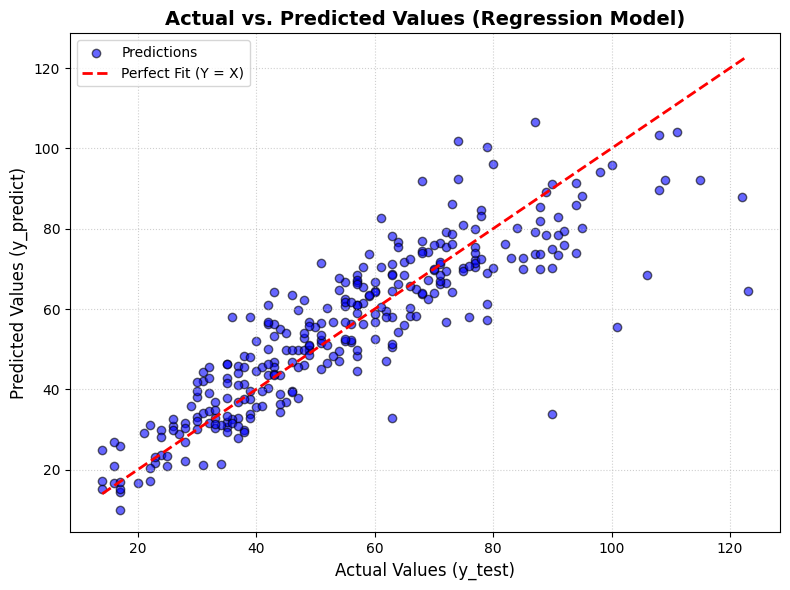

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the plot
plt.figure(figsize=(8, 6))

# 2. Scatter plot of Actual vs Predicted values
plt.scatter(y_test, y_predict, color='blue', alpha=0.6, edgecolors='k', label='Predictions')

# 3. Add a 45-degree perfect fit line
# (If predictions are perfect, all points will lie exactly on this line)
perfect_fit = [min(y_test), max(y_test)]
plt.plot(perfect_fit, perfect_fit, color='red', linestyle='--', linewidth=2, label='Perfect Fit (Y = X)')

# 4. Add labels, title, and styling
plt.title('Actual vs. Predicted Values (Regression Model)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Values (y_test)', fontsize=12)
plt.ylabel('Predicted Values (y_predict)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

# 5. Display the plot
plt.tight_layout()
plt.show()

In [65]:
# Understand Feature

# feature_score = search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
# feature_name = search.best_estimator_.named_steps['Regrassor'].feature_importances_
feature_score = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_name = full_pipeline.named_steps['Regrassor'].feature_importances_

print(feature_score)
print(feature_name)

['num__Preparation_Time_min' 'num__Courier_Experience_yrs'
 'num__Distance_km' 'cat__Weather' 'cat__Vehicle_Type'
 'cat_order__Traffic_Level' 'cat_order__Time_of_Day']
[3090 1211 4457 1475  769    0  382]
